# חיזוי מחלות לב — פרויקט למידת מכונה

מחברת זו מיישמת **מאפס (NumPy בלבד)** את כל שלבי הפרויקט על מאגר
*Heart Disease* (Kaggle: `johnsmith88/heart-disease-dataset`).
המטרה היא **סיווג בינארי**: האם למטופל יש מחלת לב (`target=1`) או לא (`target=0`).

## שאלות המחקר
1. **חיזוי מחלת לב** — האם ניתן לחזות את קיום המחלה על סמך נתוני המטופל?
2. **השוואת מודלים** — איזה מודל משיג את הביצועים הטובים ביותר?
3. **חשיבות מאפיינים** — אילו תכונות משפיעות ביותר על התחזית, והאם יש הסכמה בין המודלים?

## המודלים (מומשו מאפס)
1. **k-Nearest Neighbors** (הרצאה 10)
2. **עץ החלטה / Decision Tree** (הרצאה 11)
3. **AdaBoost** (הרצאה 8)
4. **רשת נוירונים / Neural Network** — MLP, מבוסס על תפיסת ה-Perceptron (הרצאה 6) והרגרסיה הלוגיסטית (הרצאה 14)

## 1. הכנת הסביבה (Setup)

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))  # make `src` importable

import numpy as np
import pandas as pd
from IPython.display import Image, display

from src import data_loader as dl
from src import metrics, evaluation as ev, plots
from src.preprocessing import train_test_split, StandardScaler, kfold_indices
from src.models import (
    KNNClassifier, DecisionTreeClassifier, AdaBoostClassifier, NeuralNetwork,
)

SEED = 42
np.random.seed(SEED)
pd.set_option("display.float_format", lambda v: f"{v:.3f}")
print("Environment ready.")

Environment ready.


## 2. טעינת הנתונים ותיאור המאגר

המאגר כולל 13 מאפיינים רפואיים (גיל, מין, סוג כאב בחזה, לחץ דם, כולסטרול, דופק מרבי ועוד)
ועמודת מטרה בינארית. נטען את הגרסה הגולמית ואת הגרסה ללא כפילויות, ונשווה ביניהן.

In [2]:
raw_df = dl.load_data(dedup=False)
df = dl.load_data(dedup=True)          # de-duplicated — used for honest evaluation
X, y, feature_names = dl.get_Xy(df)

summary = dl.dataset_summary()
print("Raw rows:        ", summary["n_rows_raw"])
print("Unique rows:     ", summary["n_rows_unique"])
print("Duplicate rows:  ", summary["n_duplicates"])
print("Missing values:  ", summary["n_missing"])
print("Target (unique): ", summary["target_balance_unique"])
df.head()

Raw rows:         1025
Unique rows:      302
Duplicate rows:   723
Missing values:   0
Target (unique):  {1: 164, 0: 138}


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.000,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.100,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.600,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.000,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.900,1,3,2,0


In [3]:
# Descriptions of each feature
pd.DataFrame(
    [(c, dl.FEATURE_DESCRIPTIONS[c]) for c in feature_names + ["target"]],
    columns=["feature", "description"],
)

,feature,description
0,age,Age (years)
1,sex,"Sex (1=male, 0=female)"
2,cp,Chest pain type (0-3)
3,trestbps,Resting blood pressure (mm Hg)
4,chol,Serum cholesterol (mg/dl)
5,fbs,Fasting blood sugar > 120 mg/dl (1/0)
6,restecg,Resting ECG result (0-2)
7,thalach,Maximum heart rate achieved
8,exang,Exercise-induced angina (1/0)
9,oldpeak,ST depression induced by exercise


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,302.000,54.421,9.048,29.000,48.000,55.500,61.000,77.000
sex,302.000,0.682,0.466,0.000,0.000,1.000,1.000,1.000
cp,302.000,0.964,1.032,0.000,0.000,1.000,2.000,3.000
trestbps,302.000,131.603,17.563,94.000,120.000,130.000,140.000,200.000
chol,302.000,246.500,51.753,126.000,211.000,240.500,274.750,564.000
fbs,302.000,0.149,0.357,0.000,0.000,0.000,0.000,1.000
restecg,302.000,0.526,0.526,0.000,0.000,1.000,1.000,2.000
thalach,302.000,149.570,22.904,71.000,133.250,152.500,166.000,202.000
exang,302.000,0.328,0.470,0.000,0.000,0.000,1.000,1.000
oldpeak,302.000,1.043,1.161,0.000,0.000,0.800,1.600,6.200


## 3. ניתוח חוקר (EDA)

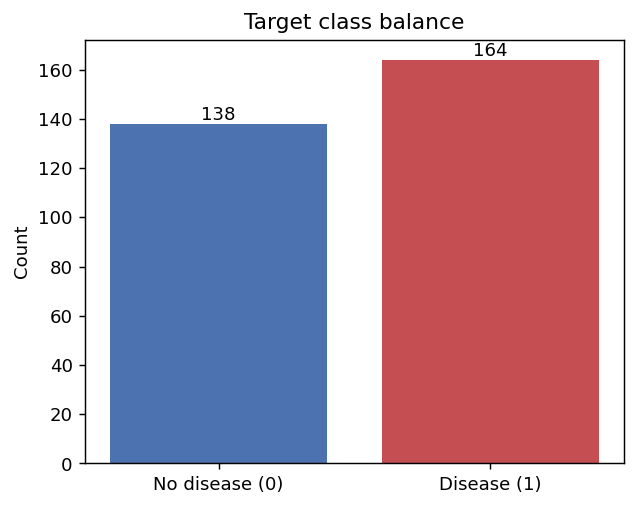

In [5]:
display(Image(plots.plot_class_balance(y)))

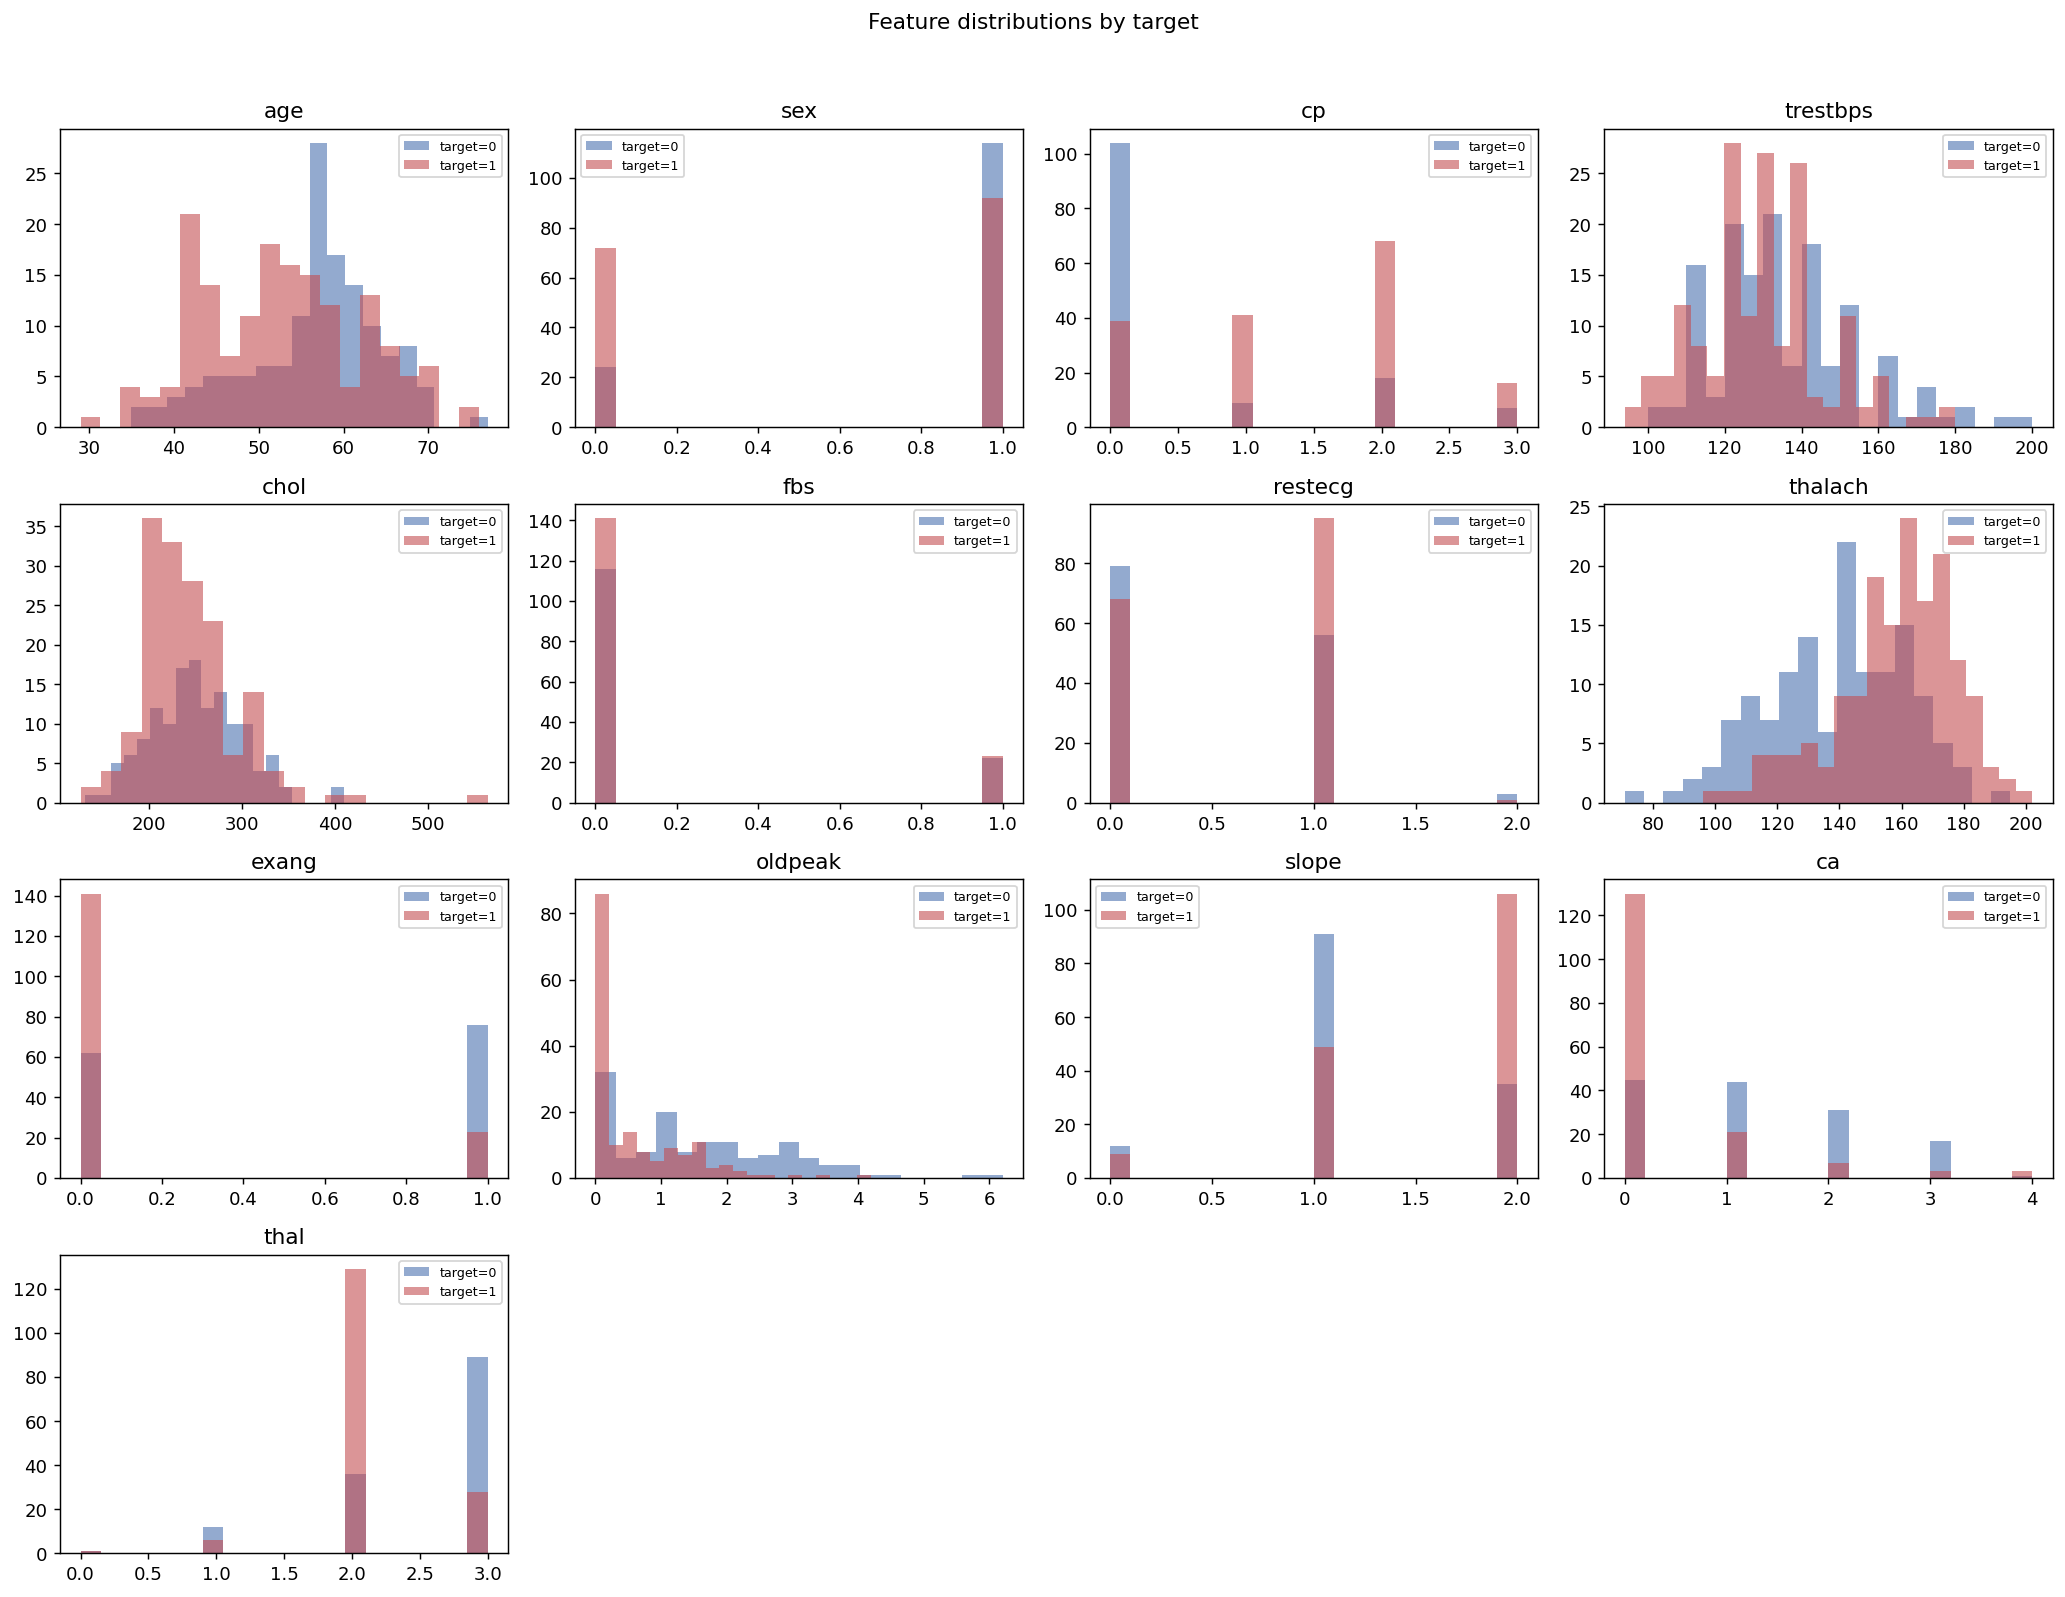

In [6]:
display(Image(plots.plot_feature_histograms(df, feature_names)))

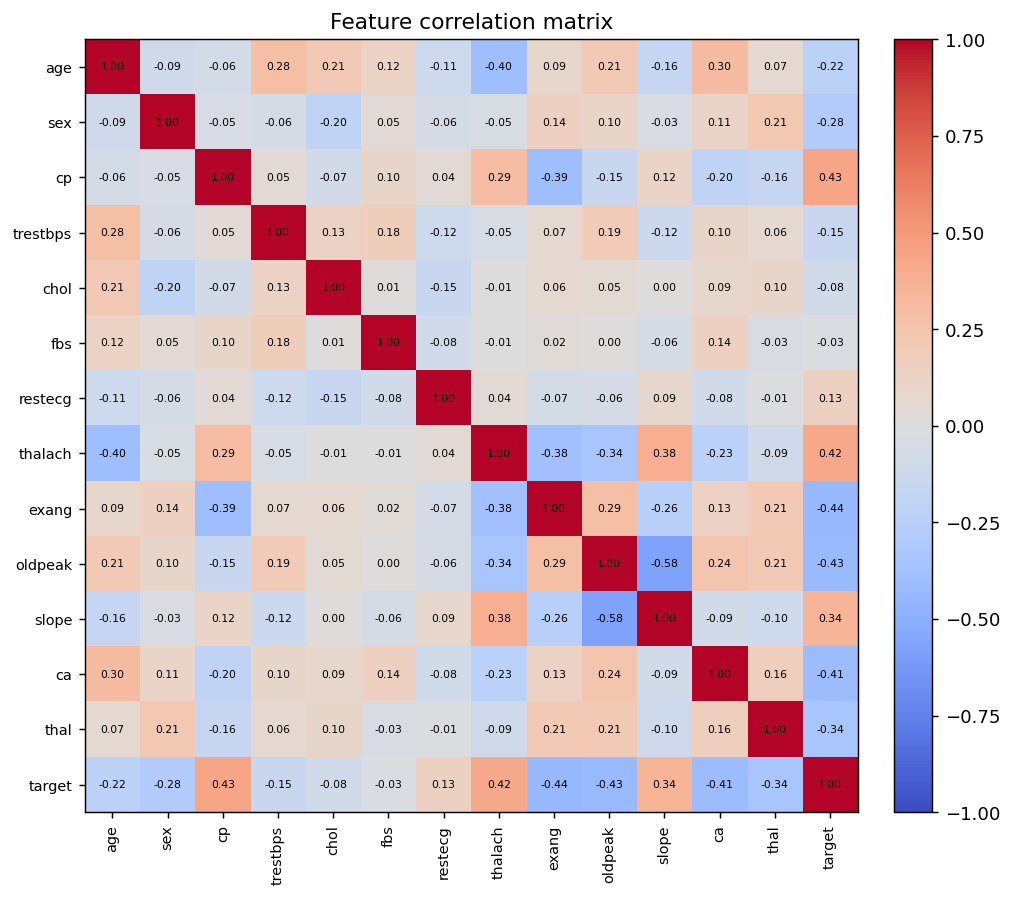

In [7]:
display(Image(plots.plot_correlation_heatmap(df, feature_names + ['target'])))

### 3.1 הפחתת ממד לצורך ויזואליזציה (הרצאה 15)

נשליך את הנתונים לדו-ממד בשתי דרכים: **PCA** (מהאלגברה הלינארית, באמצעות SVD)
ו-**היטל אקראי של Johnson–Lindenstrauss**. שתי השיטות מראות הפרדה חלקית בין החולים לבריאים.

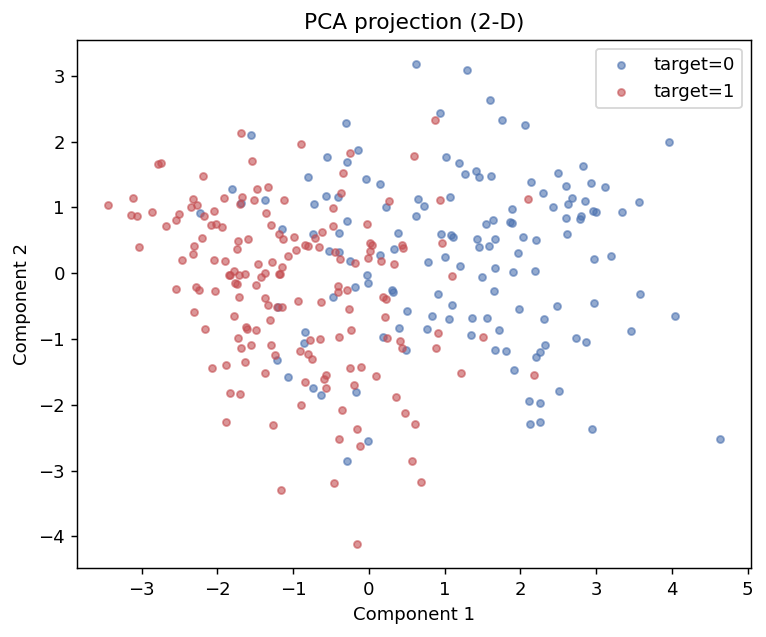

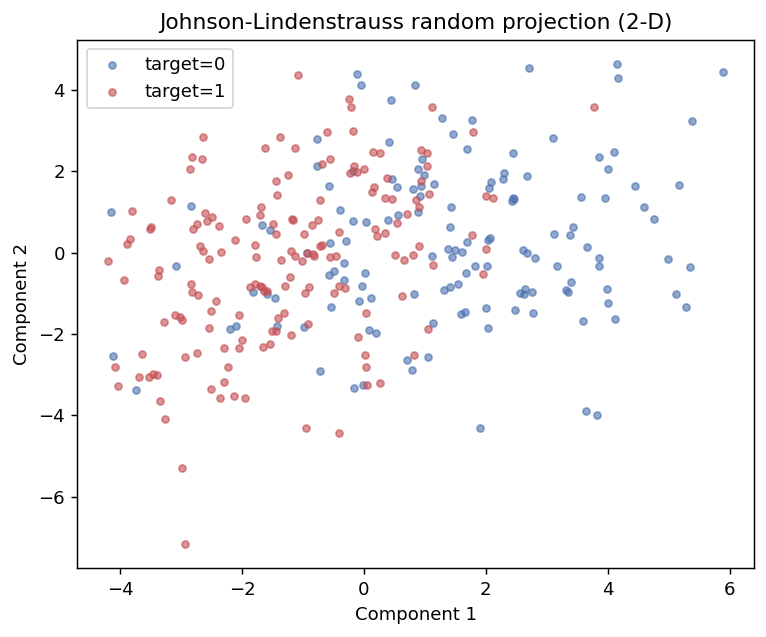

In [8]:
display(Image(plots.plot_2d_projection(X, y, method="pca")))
display(Image(plots.plot_2d_projection(X, y, method="jl")))

## 4. אתגר מרכזי: כפילויות ודליפת מידע (Data Leakage)

גרסת ה-Kaggle מכילה **723 שורות כפולות** (1025 → 302 ייחודיות). פיצול אקראי מציב
עותקים זהים גם ב-train וגם ב-test, כך שמודל "משנן" מקבל דיוק מנופח. נדגים זאת:
מודלים בעלי יכולת שינון (1-NN, עץ מלא) מגיעים ל-100% על הנתונים עם הכפילויות,
ולדיוק ריאליסטי בלבד לאחר הסרתן.

In [9]:
Xr, yr, _ = dl.get_Xy(raw_df)   # raw (with duplicates)
Xu, yu, _ = dl.get_Xy(df)       # unique

experiments = {
    "1-NN":                 (lambda: KNNClassifier(k=1), True),
    "5-NN":                 (lambda: KNNClassifier(k=5), True),
    "Decision Tree (full)": (lambda: DecisionTreeClassifier(max_depth=None), False),
    "Decision Tree (d=4)":  (lambda: DecisionTreeClassifier(max_depth=4), False),
}

rows = []
for name, (factory, scale) in experiments.items():
    e = ev.duplicate_leakage_experiment(factory, Xr, yr, Xu, yu, seed=SEED, scale=scale)
    rows.append({
        "model": name,
        "acc_with_duplicates": e["accuracy_with_duplicates"],
        "acc_deduplicated": e["accuracy_deduplicated"],
        "gap": e["accuracy_with_duplicates"] - e["accuracy_deduplicated"],
    })

leakage_df = pd.DataFrame(rows)
leakage_df

,model,acc_with_duplicates,acc_deduplicated,gap
0,1-NN,1.000,0.770,0.230
1,5-NN,0.873,0.869,0.004
2,Decision Tree (full),1.000,0.787,0.213
3,Decision Tree (d=4),0.854,0.738,0.116


**מסקנה:** הפער (`gap`) מדגים את הדליפה. לכן **כל ההערכה בהמשך מתבצעת על הנתונים
ללא כפילויות בלבד** — זו הדרך הישרה למדוד הכללה אמיתית.

## 5. עיבוד מקדים ופיצול

נפצל ל-train/test בשמירה על יחס המחלקות (stratified), ונתקנן (z-score) על בסיס ה-train
בלבד. מודלים מבוססי מרחק/גרדיאנט (k-NN, רשת נוירונים) משתמשים בנתונים המתוקננים;
עצים ו-AdaBoost משתמשים בערכים המקוריים (חיתוכי סף אינם רגישים לסקלה).

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, seed=SEED, stratify=True
)
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)
print("Train:", X_train.shape, " Test:", X_test.shape)
print("Train balance:", np.bincount(y_train), " Test balance:", np.bincount(y_test))

Train: (241, 13)  Test: (61, 13)
Train balance: [110 131]  Test balance: [28 33]


## 6. מודל 1 — k-Nearest Neighbors (הרצאה 10)

CV accuracy per k: {1: np.float64(0.768), 3: np.float64(0.776), 5: np.float64(0.796), 7: np.float64(0.801), 9: np.float64(0.796), 11: np.float64(0.809), 15: np.float64(0.809), 21: np.float64(0.792), 31: np.float64(0.792)}
Best k = 11


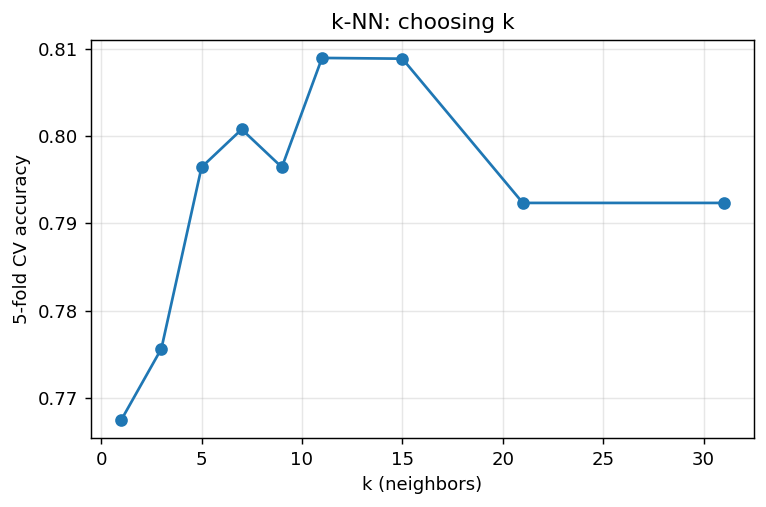

In [11]:
k_values = [1, 3, 5, 7, 9, 11, 15, 21, 31]
cv_acc = []
for k in k_values:
    scores = ev.cross_val_score(lambda k=k: KNNClassifier(k=k), X_train, y_train,
                                n_splits=5, seed=SEED, scale=True)
    cv_acc.append(scores.mean())

best_k = k_values[int(np.argmax(cv_acc))]
print("CV accuracy per k:", {k: round(a, 3) for k, a in zip(k_values, cv_acc)})
print("Best k =", best_k)
display(Image(plots.plot_curve(k_values, cv_acc, "k (neighbors)",
            "5-fold CV accuracy", "k-NN: choosing k", name="knn_k_curve.png")))

## 7. מודל 2 — עץ החלטה (הרצאה 11)

Best max_depth = 5  (CV acc=0.789)


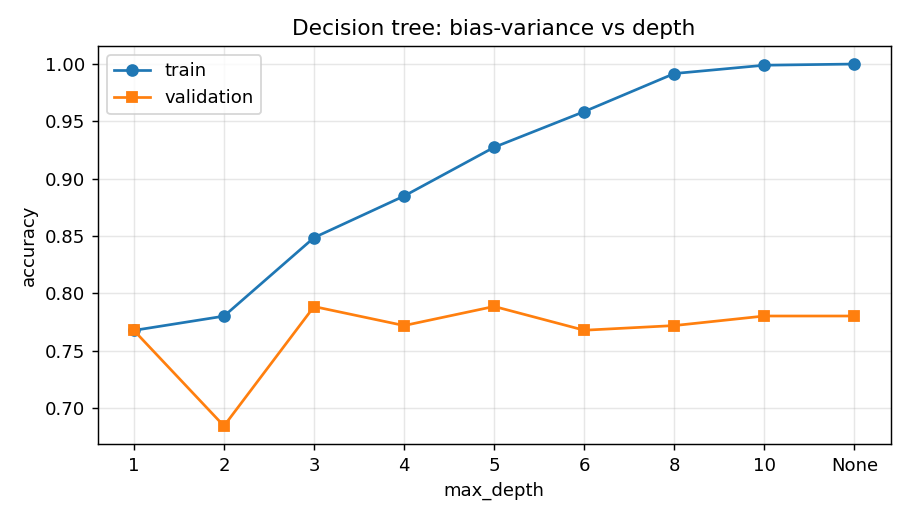

In [12]:
depths = [1, 2, 3, 4, 5, 6, 8, 10, None]
train_acc, val_acc = [], []
for d in depths:
    tr_scores, va_scores = [], []
    for tr_idx, va_idx in kfold_indices(y_train, n_splits=5, seed=SEED):
        m = DecisionTreeClassifier(criterion="entropy", max_depth=d)
        m.fit(X_train[tr_idx], y_train[tr_idx])
        tr_scores.append(metrics.accuracy(y_train[tr_idx], m.predict(X_train[tr_idx])))
        va_scores.append(metrics.accuracy(y_train[va_idx], m.predict(X_train[va_idx])))
    train_acc.append(np.mean(tr_scores)); val_acc.append(np.mean(va_scores))

labels = [str(d) if d is not None else "None" for d in depths]
best_depth = depths[int(np.argmax(val_acc))]
print("Best max_depth =", best_depth, " (CV acc=%.3f)" % max(val_acc))

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(labels, train_acc, "o-", label="train")
ax.plot(labels, val_acc, "s-", label="validation")
ax.set_xlabel("max_depth"); ax.set_ylabel("accuracy")
ax.set_title("Decision tree: bias-variance vs depth"); ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout(); fig.savefig("../figures/tree_depth_curve.png", dpi=130); plt.close(fig)
display(Image("../figures/tree_depth_curve.png"))

עקומת ה-overfitting ממחישה את עקרון ההכללה מהרצאות **PAC ו-VC-dimension**: עץ עמוק יותר
מתאים בצורה כמעט מושלמת ל-train (דיוק→1) אך ביצועי ה-validation מתחילים לרדת — מורכבות
גבוהה מדי פוגעת בהכללה.

## 8. מודל 3 — AdaBoost (הרצאה 8)

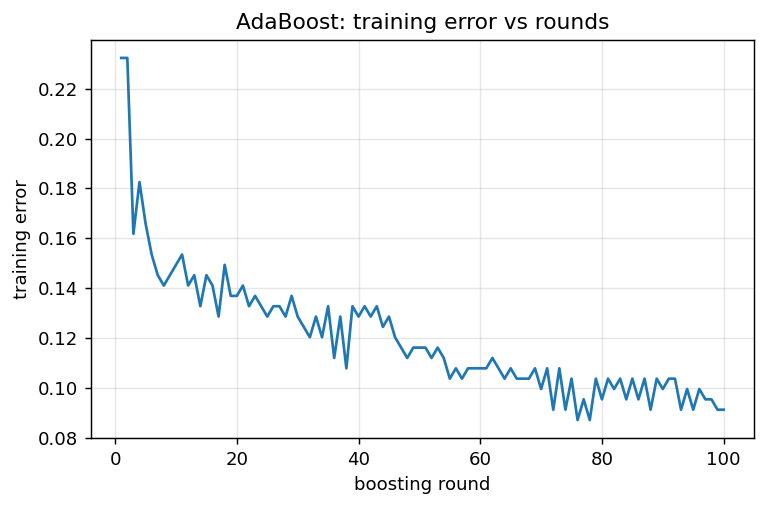

CV accuracy per T: {1: np.float64(0.768), 5: np.float64(0.788), 10: np.float64(0.805), 20: np.float64(0.793), 30: np.float64(0.793), 50: np.float64(0.784), 75: np.float64(0.772), 100: np.float64(0.768)}
Best n_estimators = 10


In [13]:
ada = AdaBoostClassifier(n_estimators=100).fit(X_train, y_train)
display(Image(plots.plot_curve(range(1, len(ada.train_errors_) + 1),
            ada.train_errors_, "boosting round", "training error",
            "AdaBoost: training error vs rounds", name="adaboost_rounds.png",
            marker="")))

# Choose the number of rounds by 5-fold CV.
round_grid = [1, 5, 10, 20, 30, 50, 75, 100]
cv_round = []
for T in round_grid:
    s = ev.cross_val_score(lambda T=T: AdaBoostClassifier(n_estimators=T),
                           X_train, y_train, n_splits=5, seed=SEED, scale=False)
    cv_round.append(s.mean())
best_T = round_grid[int(np.argmax(cv_round))]
print("CV accuracy per T:", {T: round(a, 3) for T, a in zip(round_grid, cv_round)})
print("Best n_estimators =", best_T)

חסם שגיאת האימון של AdaBoost מהרצאה 8 הוא $\prod_t 2\sqrt{\epsilon_t(1-\epsilon_t)}$,
ולכן שגיאת האימון יורדת (כמעט) מונוטונית עם מספר הסבבים — כפי שנראה בעקומה.

## 9. מודל 4 — רשת נוירונים (MLP, הרצאות 6 ו-14)

Numerical gradient check (relative diff) = 5.02e-10  -> PASS
Final training loss = 0.0567
Test accuracy = 0.754


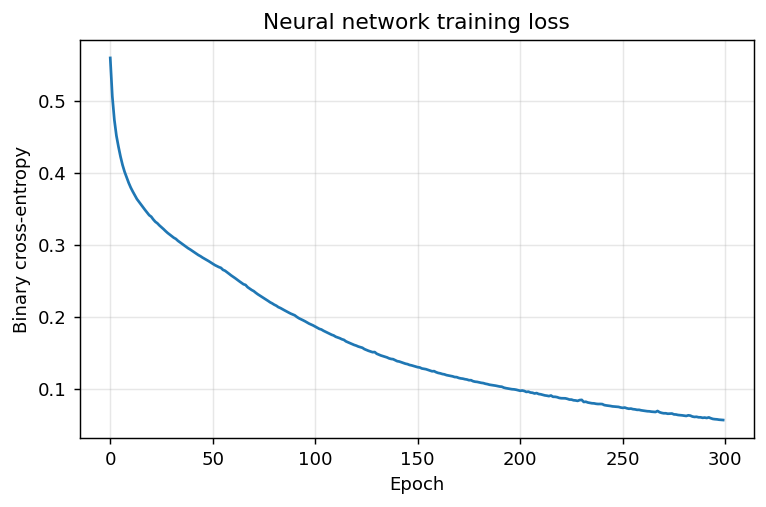

In [14]:
# Verify back-propagation with a numerical gradient check.
gc = NeuralNetwork(hidden_layers=(8,), seed=0).gradient_check(X_train_s[:20], y_train[:20])
print(f"Numerical gradient check (relative diff) = {gc:.2e}  -> {'PASS' if gc < 1e-5 else 'FAIL'}")

nn = NeuralNetwork(hidden_layers=(16,), activation="relu", lr=0.1,
                   epochs=300, batch_size=32, l2=1e-4, seed=SEED)
nn.fit(X_train_s, y_train)
print("Final training loss = %.4f" % nn.loss_history_[-1])
print("Test accuracy = %.3f" % metrics.accuracy(y_test, nn.predict(X_test_s)))
display(Image(plots.plot_nn_loss(nn.loss_history_)))

## 10. השוואת מודלים (שאלת מחקר 2)

In [15]:
# Final tuned models.
final_models = {
    "k-NN":          (lambda: KNNClassifier(k=best_k), True),
    "Decision Tree": (lambda: DecisionTreeClassifier(criterion="entropy", max_depth=best_depth), False),
    "AdaBoost":      (lambda: AdaBoostClassifier(n_estimators=best_T), False),
    "Neural Net":    (lambda: NeuralNetwork(hidden_layers=(16,), lr=0.1, epochs=300,
                                            batch_size=32, l2=1e-4, seed=SEED), True),
}

results, fitted, roc_data = {}, {}, {}
for name, (factory, scale) in final_models.items():
    Xtr, Xte = (X_train_s, X_test_s) if scale else (X_train, X_test)
    model = factory(); model.fit(Xtr, y_train)
    fitted[name] = (model, scale)
    results[name] = ev.evaluate_model(model, Xtr, y_train, Xte, y_test)
    proba = model.predict_proba(Xte)[:, 1]
    fpr, tpr, _ = metrics.roc_curve(y_test, proba)
    roc_data[name] = (fpr, tpr, metrics.auc(fpr, tpr))

results_df = pd.DataFrame(results).T[["accuracy", "precision", "recall", "f1", "auc"]]
results_df = results_df.sort_values("accuracy", ascending=False)
results_df

,accuracy,precision,recall,f1,auc
k-NN,0.885,0.882,0.909,0.896,0.926
Decision Tree,0.787,0.812,0.788,0.800,0.861
AdaBoost,0.787,0.857,0.727,0.787,0.929
Neural Net,0.754,0.781,0.758,0.769,0.867


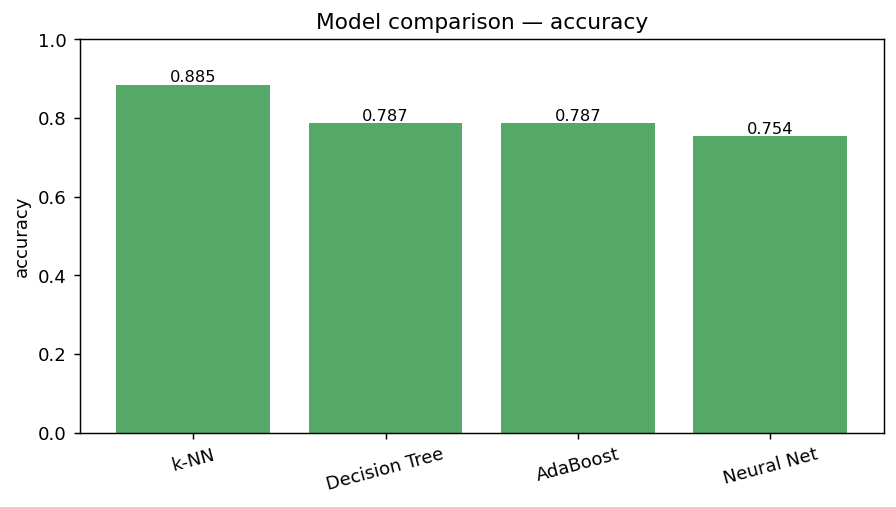

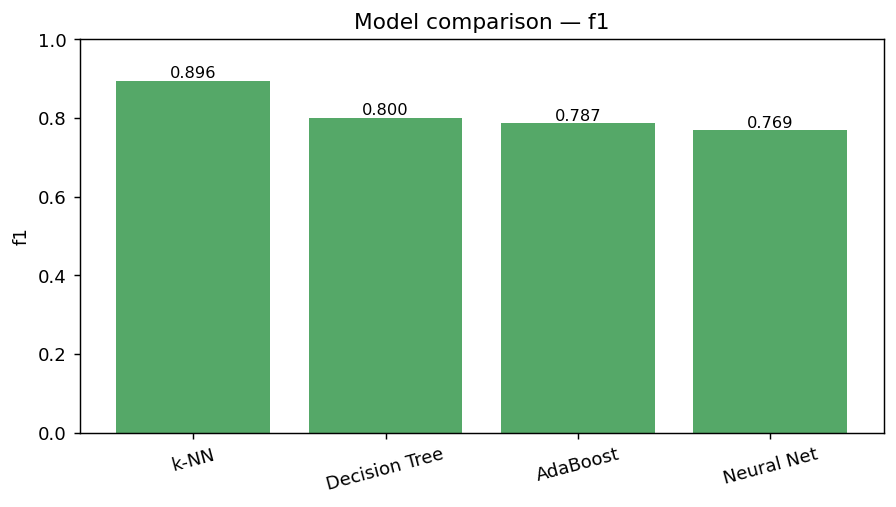

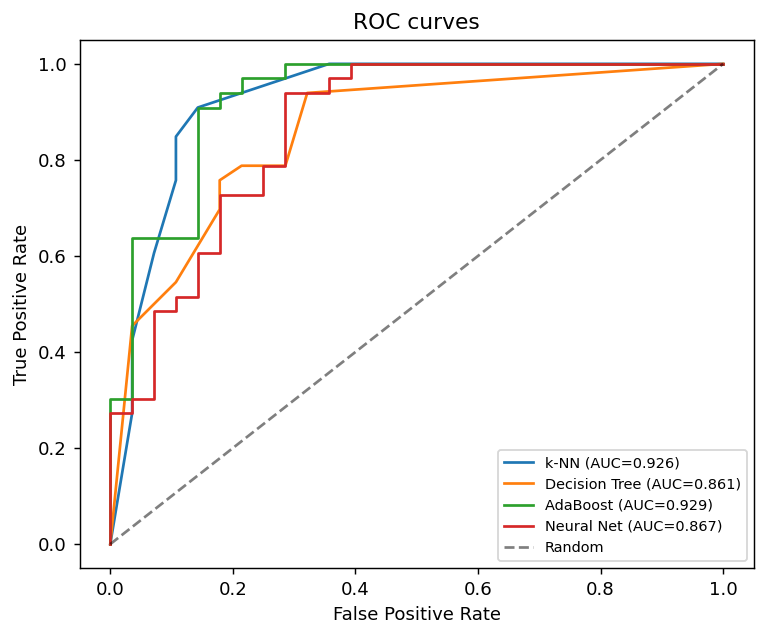

In [16]:
display(Image(plots.plot_model_comparison(results, metric="accuracy")))
display(Image(plots.plot_model_comparison(results, metric="f1", name="model_comparison_f1.png")))
display(Image(plots.plot_roc_curves(roc_data)))

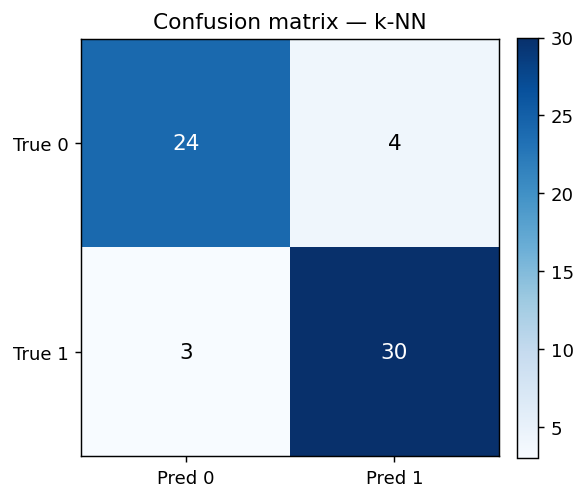

Best model: k-NN


In [17]:
# Confusion matrix of the best model.
best_name = results_df.index[0]
best_model, best_scale = fitted[best_name]
Xte = X_test_s if best_scale else X_test
cm = metrics.confusion_matrix(y_test, best_model.predict(Xte))
display(Image(plots.plot_confusion_matrix(cm, name="confusion_matrix_best.png",
            title=f"Confusion matrix — {best_name}")))
print("Best model:", best_name)

## 11. חשיבות מאפיינים (שאלת מחקר 3)

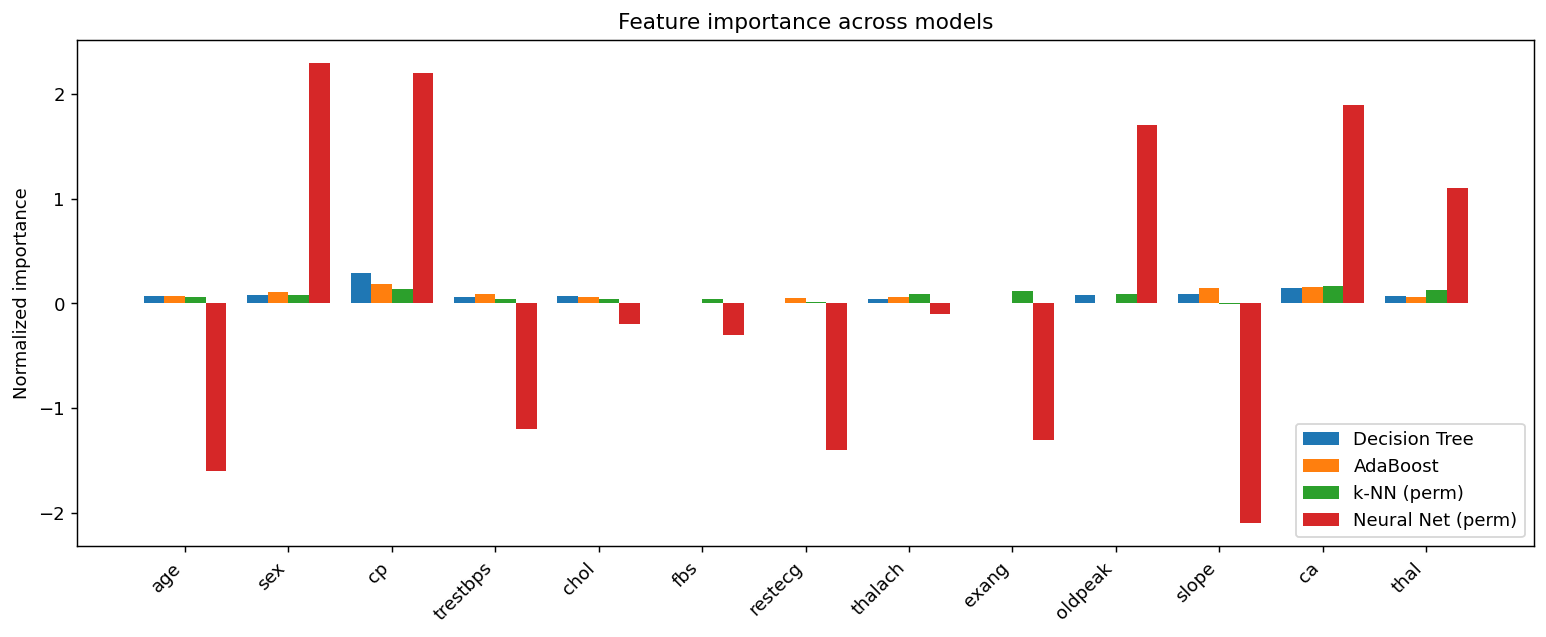

,Decision Tree,AdaBoost,k-NN (perm),Neural Net (perm),mean
cp,0.292,0.190,0.134,0.126,0.186
ca,0.145,0.154,0.165,0.109,0.143
sex,0.082,0.107,0.082,0.132,0.101
thal,0.069,0.062,0.130,0.063,0.081
oldpeak,0.084,0.000,0.087,0.098,0.067
thalach,0.042,0.062,0.087,-0.006,0.046
chol,0.072,0.065,0.039,-0.011,0.041
trestbps,0.057,0.091,0.039,-0.069,0.030
age,0.068,0.074,0.056,-0.092,0.027
slope,0.089,0.143,-0.009,-0.121,0.026


In [18]:
importances = {}

# Model-specific importances.
dt_full = DecisionTreeClassifier(criterion="entropy", max_depth=best_depth).fit(X_train, y_train)
importances["Decision Tree"] = dt_full.feature_importances_
importances["AdaBoost"] = fitted["AdaBoost"][0].feature_importances_

# Permutation importance (model-agnostic) for k-NN and the neural net.
knn_model = fitted["k-NN"][0]
importances["k-NN (perm)"] = ev.permutation_importance(knn_model, X_test_s, y_test, seed=SEED)
nn_model = fitted["Neural Net"][0]
importances["Neural Net (perm)"] = ev.permutation_importance(nn_model, X_test_s, y_test, seed=SEED)

display(Image(plots.plot_feature_importances(importances, feature_names)))

# Average rank across models -> consensus.
imp_df = pd.DataFrame({m: np.asarray(v) / (np.sum(np.abs(v)) or 1)
                       for m, v in importances.items()}, index=feature_names)
imp_df["mean"] = imp_df.mean(axis=1)
imp_df.sort_values("mean", ascending=False)

## 12. תשובות לשאלות המחקר

**1. חיזוי מחלת לב.** כן — לאחר הסרת הכפילויות, כל המודלים משיגים דיוק גבוה משמעותית
מ-50% (קו הבסיס האקראי), כך שניתן לחזות מחלת לב מנתוני המטופל ברמת דיוק שימושית.

**2. השוואת מודלים.** ראו טבלת התוצאות והגרפים בסעיף 10. המודל המוביל מזוהה אוטומטית
(`best_name`) לפי דיוק המבחן, עם השוואת precision/recall/F1/AUC.

**3. חשיבות מאפיינים.** ראו סעיף 11. המאפיינים החוזרים כחשובים על פני מספר מודלים
(למשל `cp`, `thalach`, `oldpeak`, `ca`, `thal`, `exang`) מצביעים על הסכמה חלקית בין
השיטות, אף שכל מודל שוקל אותם מעט אחרת.

## 13. אתגרים ולקחים
- **דליפת כפילויות** הייתה האתגר המרכזי; ההתמודדות הייתה הסרת כפילויות והערכה ישרה.
- **תקנון** היה קריטי ל-k-NN ולרשת הנוירונים, וחסר משמעות לעצים/AdaBoost.
- **Overfitting** בעצים ובמספר סבבי ה-AdaBoost נשלט באמצעות תיקוף צולב (cross-validation).
- **אימות נגזרות** ברשת הנוירונים (gradient check) ווידא את נכונות ה-back-propagation.

המסקנות המלאות מופיעות בקבצי הדוח בתיקיית `reports/`.